# Исследовательский анализ данных

## Give Me Some Credit

### Цель проекта

Необходимо разработать модель, которая оценивает вероятность возникновения серьёзной просрочки
по кредитным обязательствам в течение следующих двух лет.

Целевая переменная — `SeriousDlqin2yrs`.

Задачи этапа EDA:

- изучить структуру датасета;
- проверить качество данных;
- исследовать распределение целевой переменной;
- изучить распределения признаков;
- исследовать связь признаков с целевой переменной;
- сформировать выводы для дальнейшего этапа подготовки данных и построения моделей.

In [1]:
# импорты и загрузка
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
# загрузка данных 
train = pd.read_csv("../data/raw/cs-training.csv")

train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# общая информация 
print(f"Размер датасета: {train.shape[0]:,} строк, {train.shape[1]} столбцов")
train.info()

Размер датасета: 150,000 строк, 12 столбцов
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWors

In [4]:
# статистические данные 
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


In [5]:
# дубликаты 
print(f"Количество дубликатов: {train.duplicated().sum()}")

Количество дубликатов: 0


In [6]:
# пропуски 
missing = train.isna().sum()
missing_pct = train.isna().mean() * 100

missing_table = (
    pd.DataFrame({
        "missing_count": missing,
        "missing_pct": missing_pct
    })
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

display(missing_table)

,missing_count,missing_pct
MonthlyIncome,29731,19.820667
NumberOfDependents,3924,2.616000


Пропуски присутствуют только в `MonthlyIncome` и `NumberOfDependents`.

Наибольшая доля пропусков приходится на `MonthlyIncome` — около 19.8% наблюдений.
Удалять строки с пропущенными значениями на этапе EDA не будем: способ обработки пропусков
будет определён после разделения данных на обучающую и валидационную выборки.

In [7]:
# проверка на аномальные значения 
train["age"].min(), train["age"].max()

(np.int64(0), np.int64(109))

In [8]:
print(f"Количество записей с age = 0: {(train['age'] == 0).sum()}")

Количество записей с age = 0: 1


In [9]:
late_columns = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

for column in late_columns:
    print(f"{column}:")
    print(train[column].value_counts().sort_index().tail())

NumberOfTime30-59DaysPastDueNotWorse:
NumberOfTime30-59DaysPastDueNotWorse
11      1
12      2
13      1
96      5
98    264
Name: count, dtype: int64
NumberOfTimes90DaysLate:
NumberOfTimes90DaysLate
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64
NumberOfTime60-89DaysPastDueNotWorse:
NumberOfTime60-89DaysPastDueNotWorse
8       2
9       1
11      1
96      5
98    264
Name: count, dtype: int64


В данных обнаружена одна запись с `age = 0`, которая требует обработки как некорректное значение.

В трёх признаках, связанных с просрочками, встречаются значения `96` и `98`.
Они образуют отдельную группу и не должны интерпретироваться как обычное количество просрочек.
Вопрос их обработки будет решён на этапе подготовки признаков.

In [10]:
# целевая переменная
target_counts = train["SeriousDlqin2yrs"].value_counts()

display(
    pd.DataFrame({
        "count": target_counts,
        "share": train["SeriousDlqin2yrs"].value_counts(normalize=True)
    })
)

,count,share
SeriousDlqin2yrs,,
0,139974,0.93316
1,10026,0.06684


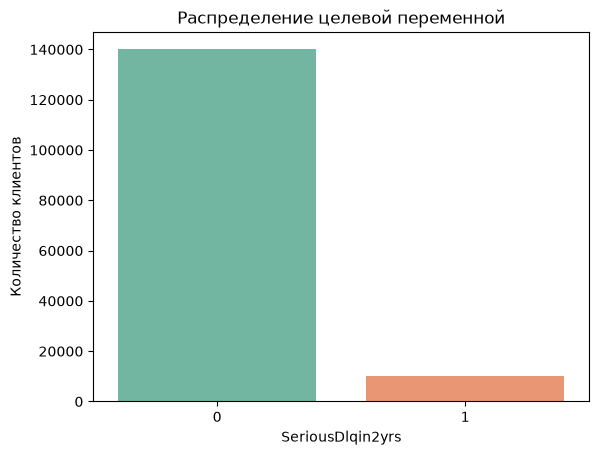

In [11]:
sns.countplot(data=train, x="SeriousDlqin2yrs", hue="SeriousDlqin2yrs", palette="Set2", legend=False)

plt.title("Распределение целевой переменной")
plt.xlabel("SeriousDlqin2yrs")
plt.ylabel("Количество клиентов")

plt.show()

Целевая переменная существенно несбалансирована:

- класс 0 — 93.3%;
- класс 1 — 6.7%.

Поэтому при построении моделей одной accuracy будет недостаточно для оценки качества.
На этапе моделирования будем использовать метрики, учитывающие дисбаланс классов.

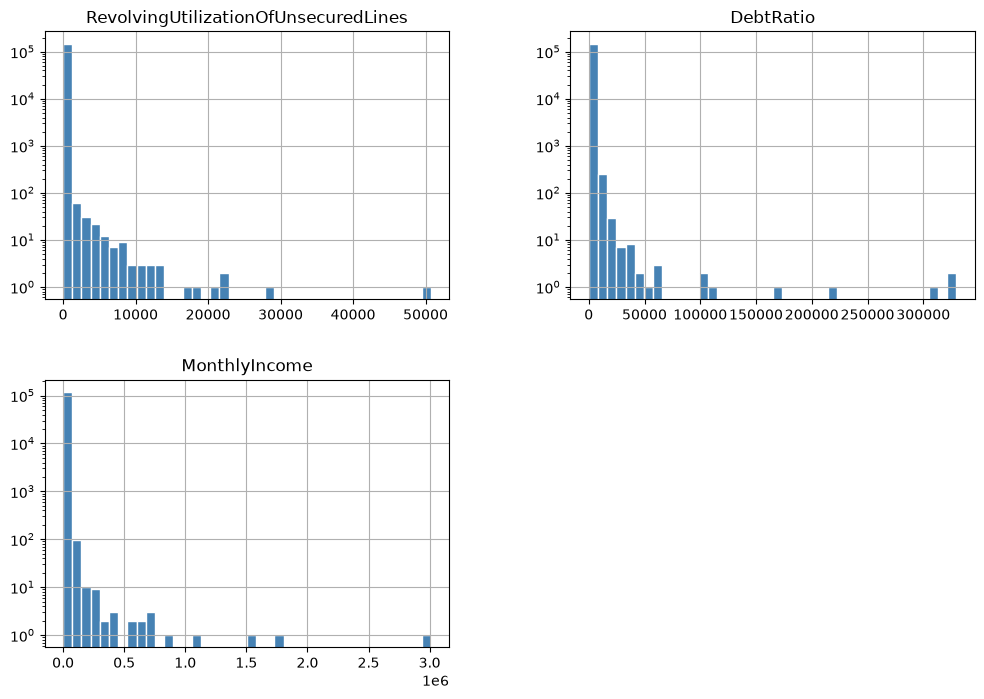

In [12]:
financial_features = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome"
]

train[financial_features].hist(figsize=(12, 8), bins=40, log=True, color="steelblue", edgecolor="white")

plt.xlabel("Количество клиентов")
plt.ylabel("значение")

plt.show()

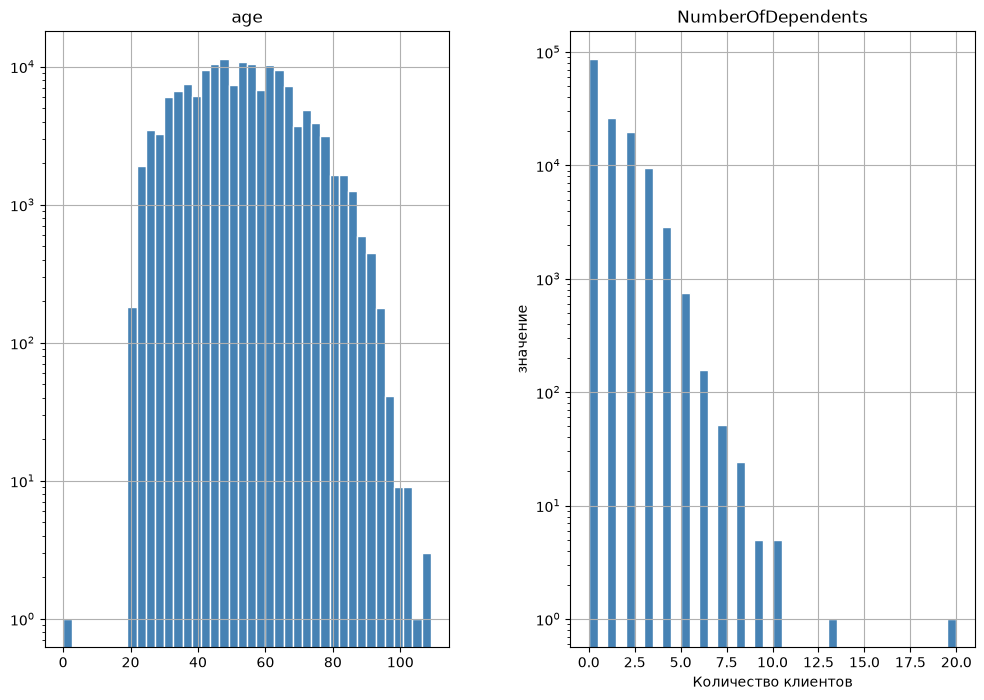

In [13]:
train[["age", "NumberOfDependents"]].hist(figsize=(12, 8), bins=40, log=True, color="steelblue", edgecolor="white")

plt.xlabel("Количество клиентов")
plt.ylabel("значение")
plt.show()

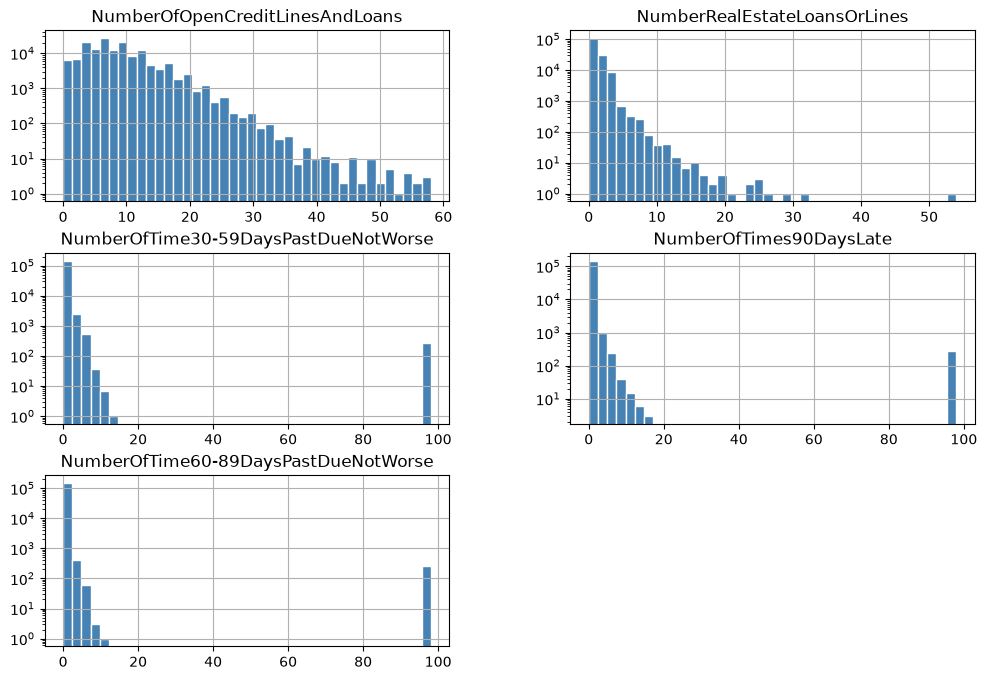

In [14]:
credit_features = [
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

train[credit_features].hist(figsize=(12, 8), bins=40, log=True, color="steelblue", edgecolor="white")

plt.show()

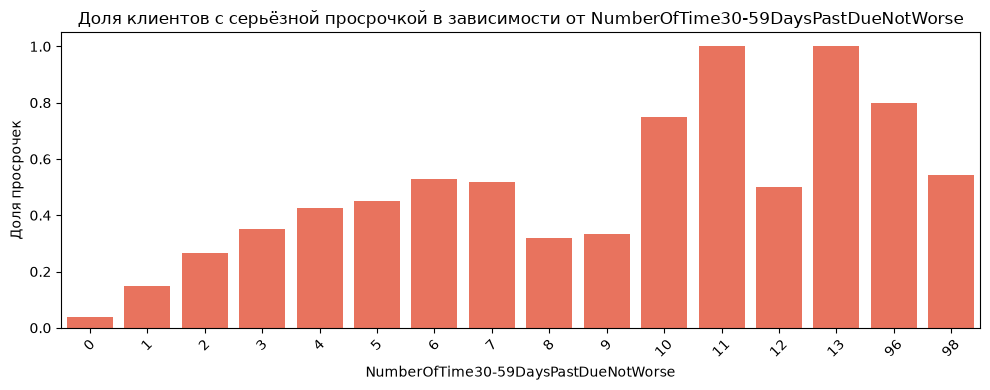

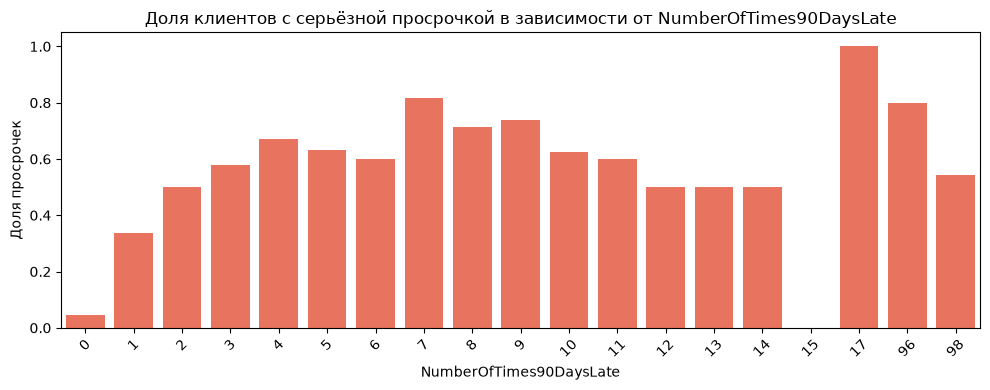

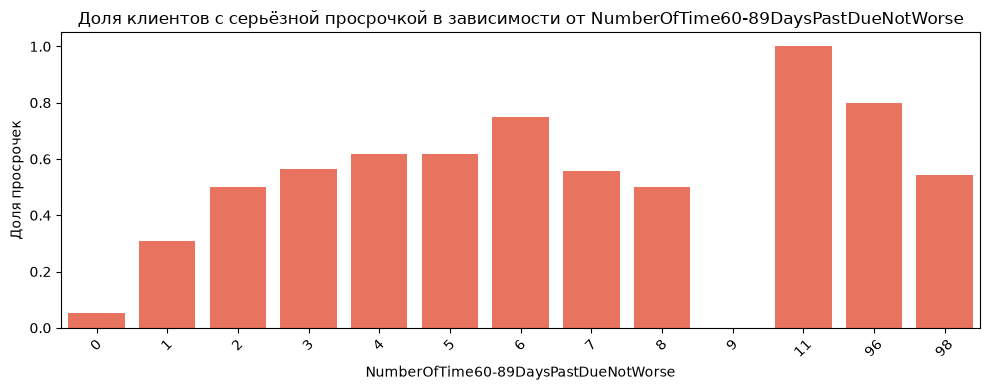

In [15]:
for column in late_columns:
    risk_by_value = train.groupby(column)["SeriousDlqin2yrs"].mean().reset_index()

    plt.figure(figsize=(10, 4))
    sns.barplot(data=risk_by_value, x=column, y="SeriousDlqin2yrs", color="tomato")

    plt.title(f"Доля клиентов с серьёзной просрочкой в зависимости от {column}", fontsize=12)
    plt.xlabel(column, fontsize=10)
    plt.ylabel("Доля просрочек", fontsize=10)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

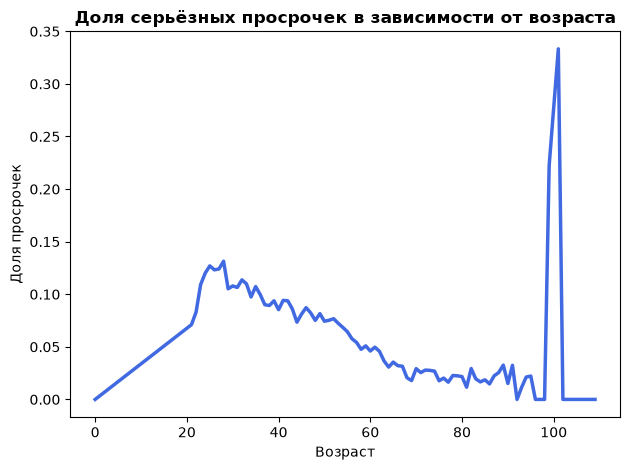

In [16]:
train.groupby("age")["SeriousDlqin2yrs"].mean().plot(color="royalblue", linewidth=2.5)

plt.title("Доля серьёзных просрочек в зависимости от возраста", fontsize=12, fontweight='bold')
plt.xlabel("Возраст", fontsize=10)
plt.ylabel("Доля просрочек", fontsize=10)

plt.tight_layout()
plt.show()

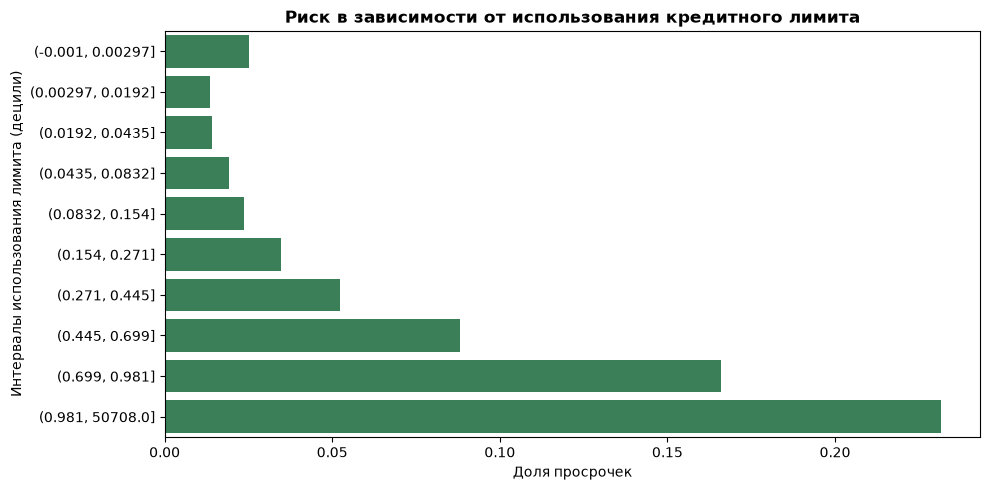

In [17]:
train["utilization_bin"] = pd.qcut(
    train["RevolvingUtilizationOfUnsecuredLines"],
    q=10,
    duplicates="drop"
)

risk_by_utilization = train.groupby("utilization_bin", observed=True)["SeriousDlqin2yrs"].mean().reset_index()

plt.figure(figsize=(10, 5))

sns.barplot(data=risk_by_utilization, x="SeriousDlqin2yrs", y="utilization_bin", color="seagreen")

plt.title("Риск в зависимости от использования кредитного лимита", fontsize=12, fontweight='bold')
plt.xlabel("Доля просрочек", fontsize=10)
plt.ylabel("Интервалы использования лимита (децили)", fontsize=10)

plt.tight_layout()
plt.show()

## Основные выводы

1. Датасет содержит 150 000 наблюдений и 12 исходных столбцов.
2. Целевая переменная `SeriousDlqin2yrs` имеет выраженный дисбаланс классов:
   положительный класс составляет около 6.7%.
3. Пропуски присутствуют в `MonthlyIncome` (19.8%) и `NumberOfDependents` (2.6%).
4. Обнаружена одна запись с некорректным значением `age = 0`.
5. В признаках, характеризующих историю просрочек, присутствуют значения `96` и `98`,
   требующие специальной обработки.
6. Распределения финансовых признаков имеют выраженную асимметрию и длинные хвосты.
7. История просрочек и другие кредитные характеристики демонстрируют связь с целевой
   переменной и требуют дальнейшего исследования при построении моделей.

### Следующий этап

На основании результатов EDA необходимо подготовить данные к моделированию:
обработать пропуски и аномальные значения, исключить технический идентификатор,
разделить данные на обучающую и валидационную выборки и построить baseline-модель.